# Лабораторна робота: DreamBooth LoRA на Kaggle

**Тема:** персоналізація Stable Diffusion за допомогою DreamBooth LoRA та офіційного training script із `diffusers`.

Цей notebook адаптовано з ідеї Hugging Face Diffusion Course DreamBooth Hackathon:

- з DreamBooth **LoRA** через офіційний script `examples/dreambooth/train_dreambooth_lora.py` із репозиторію `diffusers`.

> **Перед запуском у Kaggle:**
> 1. Відкрийте notebook у Kaggle.
> 2. Увімкніть **GPU**: `Settings → Accelerator → GPU`.
> 3. Увімкніть **Internet**.
> 4. Додайте Hugging Face token у `Add-ons → Secrets` з назвою `HF_TOKEN`.
> 5. Додайте власний dataset із 10–20 зображеннями одного об'єкта в різних ракурсах та на різних фонах або використайте демонстраційний dataset у notebook.


## 1. Мета лабораторної

Після виконання роботи студент має вміти:

1. Пояснити, що таке DreamBooth і чим DreamBooth LoRA відрізняється від повного fine-tuning.
2. Підготувати невеликий dataset із 10–20 зображень одного безпечного об'єкта.
3. Обрати `unique_token`, `class_noun` і скласти `instance_prompt`.
4. Запустити DreamBooth LoRA training через офіційний script Diffusers.
5. Згенерувати зображення до і після fine-tuning.
6. Порівняти base model і fine-tuned LoRA model.
7. Виявити ознаки overfitting та underfitting.

**Результат роботи:** набір зображень, trained LoRA weights, таблиця параметрів і короткий звіт.


## 2. Правила безпеки й дозволені типи датасетів

### Дозволено

Використовуйте один неособистий об'єкт:

- чашка;
- іграшка;
- рюкзак;
- кімнатна рослина;
- страва;
- предмет одягу;
- технічний пристрій;
- домашня тварина, якщо фото не містять приватної інформації.

### Заборонено без окремого письмового дозволу викладача

- обличчя студентів, викладачів або інших людей;
- публічні особи;
- чужі приватні фотографії;
- copyrighted characters, логотипи, чужі художні роботи;
- медичні, приватні або чутливі фото;
- NSFW, політичні маніпуляції, deepfake-сценарії;
- будь-які дані, які студент не має права використовувати.

### Практичне правило

Для цієї лабораторної найкраще тренувати модель на **предметі**, а не на людині.

Stable Diffusion v1.x краще працює з англомовними prompts, тому всі prompts у цій роботі пишемо англійською, навіть якщо звіт українською.


## 3. Перевірка GPU

Цей notebook розрахований на Kaggle GPU. Для комфортного запуску бажано мати NVIDIA GPU з 16 GB VRAM або більше.


In [4]:
import os
import sys
import subprocess
from pathlib import Path

# Робочі директорії Kaggle
WORK_DIR = Path("/kaggle/working")
INPUT_DIR = Path("/kaggle/input")
WORK_DIR.mkdir(parents=True, exist_ok=True)

# Кеш Hugging Face краще тримати в /kaggle/working, щоб не засмічувати root home.
# Важливо: ці змінні треба задати до імпорту huggingface_hub/diffusers/transformers.
os.environ["HF_HOME"] = str(WORK_DIR / ".cache" / "huggingface")
os.environ["HF_HUB_CACHE"] = str(WORK_DIR / ".cache" / "huggingface" / "hub")
os.environ["TRANSFORMERS_CACHE"] = str(WORK_DIR / ".cache" / "huggingface" / "transformers")
os.environ["DIFFUSERS_CACHE"] = str(WORK_DIR / ".cache" / "huggingface" / "diffusers")
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import torch

print("Python:", sys.version.split()[0])
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    total_vram_gb = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print(f"VRAM: {total_vram_gb:.2f} GB")
else:
    raise RuntimeError("GPU не знайдено. Увімкніть GPU в Kaggle: Settings → Accelerator → GPU.")


Python: 3.12.13
PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
VRAM: 14.56 GB


In [5]:
# Додаткова системна інформація про GPU
!nvidia-smi

Thu Jun  4 16:13:37 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8              9W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 4. Встановлення залежностей

У цій спрощеній версії ми **не клонуємо весь репозиторій Diffusers** і **не встановлюємо Diffusers з GitHub**.

Використовується стабільний PyPI-пакет:

```bash
pip install diffusers
```

Але важливий нюанс: офіційний training script `train_dreambooth_lora.py` не входить до звичайного pip-пакета `diffusers`, бо це файл з папки `examples/dreambooth` у репозиторії Diffusers. Тому notebook завантажує **тільки один script-файл**, бажано з release tag, що відповідає встановленій версії `diffusers`.

Це простіше й стабільніше для Kaggle:

- не ставимо `xformers` обов'язково;
- `bitsandbytes` не потрібен, якщо `USE_8BIT_ADAM = False`;
- `torchao` видаляється, бо в Kaggle він іноді створює конфлікти з поточною версією PyTorch/Diffusers;
- `peft` встановлюється з явною вимогою `peft>=0.17.0`, бо офіційний DreamBooth LoRA script потребує сучасної PEFT-версії.

> Якщо треба максимально автономний notebook без GitHub-завантаження script-файлу, training script можна додати до Kaggle input або вставити як окремий файл у dataset. Але звичайний PyPI-пакет `diffusers` сам по собі не містить `examples/dreambooth/train_dreambooth_lora.py`.


In [7]:
%%bash
set -e
set -x

cd /kaggle/working

echo "=== Python / pip ==="
python --version
python -m pip --version

echo "=== Install minimal stable Hugging Face diffusion stack ==="
# Не встановлюємо і не оновлюємо:
# torch, torchvision, torchaudio, xformers, bitsandbytes.
#
# Не клонуємо повний Diffusers repo.
# Встановлюємо стандартний diffusers з PyPI.
#
# Верхні межі потрібні, щоб випадково не перейти на занадто нові major-версії,
# які можуть ламати сумісність у Kaggle.

python -m pip install --no-input --disable-pip-version-check \
  "diffusers>=0.35.0,<0.37.0" \
  "transformers>=4.45.0,<5.0.0" \
  "accelerate>=0.30.0,<2.0.0" \
  "safetensors>=0.4.0" \
  "peft>=0.17.0,<1.0.0" \
  "huggingface_hub>=0.25.0,<1.0.0" \
  ftfy

echo "=== Install lightweight utilities ==="
python -m pip install --no-input --disable-pip-version-check \
  pillow \
  matplotlib \
  pandas \
  tqdm \
  requests \
  packaging

echo "=== DONE ==="

=== Python / pip ===
Python 3.12.13
pip 24.1.2 from /usr/local/lib/python3.12/dist-packages/pip (python 3.12)
=== Install minimal stable Hugging Face diffusion stack ===
=== Install lightweight utilities ===
=== DONE ===


+ cd /kaggle/working
+ echo '=== Python / pip ==='
+ python --version
+ python -m pip --version
+ echo '=== Install minimal stable Hugging Face diffusion stack ==='
+ python -m pip install --no-input --disable-pip-version-check 'diffusers>=0.35.0,<0.37.0' 'transformers>=4.45.0,<5.0.0' 'accelerate>=0.30.0,<2.0.0' 'safetensors>=0.4.0' 'peft>=0.17.0,<1.0.0' 'huggingface_hub>=0.25.0,<1.0.0' ftfy
+ echo '=== Install lightweight utilities ==='
+ python -m pip install --no-input --disable-pip-version-check pillow matplotlib pandas tqdm requests packaging
+ echo '=== DONE ==='


In [8]:
%%bash
set -e
set -x

echo "=== Optional: install xFormers ==="

python -m pip install --no-input --disable-pip-version-check --no-deps \
  "xformers==0.0.35"

echo "=== DONE ==="

=== Optional: install xFormers ===
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 38.8 MB/s eta 0:00:00
=== DONE ===


+ echo '=== Optional: install xFormers ==='
+ python -m pip install --no-input --disable-pip-version-check --no-deps xformers==0.0.35
+ echo '=== DONE ==='


In [9]:
from pathlib import Path
import urllib.request
import diffusers


print("=== Download official DreamBooth LoRA training script only ===")

work_dir = Path("/kaggle/working")
target = work_dir / "train_dreambooth_lora.py"

version = diffusers.__version__.split("+")[0]

urls = [
    f"https://raw.githubusercontent.com/huggingface/diffusers/v{version}/examples/dreambooth/train_dreambooth_lora.py",
    "https://raw.githubusercontent.com/huggingface/diffusers/main/examples/dreambooth/train_dreambooth_lora.py",
]

last_error = None

for url in urls:
    try:
        print("Trying:", url)
        urllib.request.urlretrieve(url, target)
        break
    except Exception as e:
        print("Failed:", repr(e))
        last_error = e
else:
    raise RuntimeError(f"Could not download train_dreambooth_lora.py: {last_error}")

print("Saved:", target)
print("Size bytes:", target.stat().st_size)

print("=== DONE ===")

=== Download official DreamBooth LoRA training script only ===
Trying: https://raw.githubusercontent.com/huggingface/diffusers/v0.36.0/examples/dreambooth/train_dreambooth_lora.py
Saved: /kaggle/working/train_dreambooth_lora.py
Size bytes: 59186
=== DONE ===


In [11]:
from pathlib import Path

WORK_DIR = Path("/kaggle/working")

# У спрощеній версії training script лежить прямо в /kaggle/working.
TRAIN_SCRIPT = WORK_DIR / "train_dreambooth_lora.py"

MODEL_NAME = "stable-diffusion-v1-5/stable-diffusion-v1-5"

INSTANCE_DIR = WORK_DIR / "instance_images"
LORA_OUTPUT_DIR = WORK_DIR / "dreambooth_lora_output"
LORA_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("TRAIN_SCRIPT:", TRAIN_SCRIPT)
print("TRAIN_SCRIPT exists:", TRAIN_SCRIPT.exists())
print("INSTANCE_DIR:", INSTANCE_DIR)
print("INSTANCE_DIR exists:", INSTANCE_DIR.exists())
print("LORA_OUTPUT_DIR:", LORA_OUTPUT_DIR)

assert TRAIN_SCRIPT.exists(), "train_dreambooth_lora.py не знайдено. Запустіть cell встановлення залежностей."


TRAIN_SCRIPT: /kaggle/working/train_dreambooth_lora.py
TRAIN_SCRIPT exists: True
INSTANCE_DIR: /kaggle/working/instance_images
INSTANCE_DIR exists: False
LORA_OUTPUT_DIR: /kaggle/working/dreambooth_lora_output


In [12]:
import os
import torch
import importlib
import importlib.metadata as metadata
from pathlib import Path

script = Path("/kaggle/working/train_dreambooth_lora.py")
print("Script exists:", script.exists())
print("Script:", script)

for pkg in ["diffusers", "peft", "accelerate", "transformers", "huggingface_hub", "safetensors", "torch", "pillow", "matplotlib"]:
    try:
        print(pkg, metadata.version(pkg))
    except metadata.PackageNotFoundError:
        print(pkg, "NOT INSTALLED")

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("Capability:", torch.cuda.get_device_capability(0))

# xFormers є необов'язковим.
if importlib.util.find_spec("xformers") is not None:
    import xformers
    print("xformers:", xformers.__version__)
else:
    print("xformers: NOT INSTALLED (це нормально для базової лабораторної)")

Script exists: True
Script: /kaggle/working/train_dreambooth_lora.py
diffusers 0.36.0
peft 0.18.1
accelerate 1.13.0
transformers 4.57.6
huggingface_hub 0.36.2
safetensors 0.7.0
torch 2.10.0+cu128
pillow 11.3.0
matplotlib 3.10.0
CUDA available: True
GPU: Tesla T4
Capability: (7, 5)
xformers: 0.0.35


In [13]:
# Опційно: подивитися перші рядки help для офіційного training script.
script = "/kaggle/working/train_dreambooth_lora.py"
!python {script} --help | head -40


/usr/local/lib/python3.12/dist-packages/transformers/utils/hub.py:110: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(
2026-06-04 16:16:18.151616: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780589778.329546     191 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780589778.382285     191 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780589778.803581     191 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780589778.803634     191 computation_pl

## 5. Авторизація Hugging Face

У Kaggle безпечно зберігати token через `Add-ons → Secrets`.

1. Створіть Hugging Face access token з правом `read`.
2. У Kaggle відкрийте `Add-ons → Secrets`.
3. Додайте secret з назвою `HF_TOKEN`.
4. Увімкніть доступ notebook до цього secret.

Не вставляйте token у notebook вручну і не друкуйте його в output.


In [16]:
# Авторизація через Kaggle Secrets.
# Якщо secret не налаштовано, код не зупиняє notebook: частина public моделей може завантажуватись без token.

import os

try:
    from kaggle_secrets import UserSecretsClient
    hf_token = UserSecretsClient().get_secret("HF_TOKEN")
    os.environ["HF_TOKEN"] = hf_token
    print("HF_TOKEN знайдено в Kaggle Secrets і додано в environment.")
except Exception as e:
    hf_token = os.environ.get("HF_TOKEN")
    if hf_token:
        print("HF_TOKEN уже є в environment.")
    else:
        print("HF_TOKEN не знайдено. Якщо модель gated/private, завантаження не спрацює.")
        print("Повідомлення:", repr(e))

from huggingface_hub import whoami, login

if os.environ.get("HF_TOKEN"):
    try:
        login(token=os.environ["HF_TOKEN"], add_to_git_credential=False)
        user = whoami(token=os.environ["HF_TOKEN"])
        print("Успішна авторизація Hugging Face user:", user.get("name", "unknown"))
    except Exception as e:
        print("Token знайдено, але авторизація не пройшла:", repr(e))
else:
    print("Працюємо без авторизації Hugging Face.")


Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


HF_TOKEN знайдено в Kaggle Secrets і додано в environment.
Успішна авторизація Hugging Face user: Yowyerwq


## 6. Завантаження або підготовка датасету

Є два варіанти:

### Варіант A — власний dataset студента

1. Створіть Kaggle Dataset із фото одного об'єкта.
2. Додайте його до notebook через `Add data`.
3. Вкажіть шлях у змінній `RAW_DATA_DIR` нижче.

Приклад Kaggle-шляху:

```python
RAW_DATA_DIR = "/kaggle/input/my-cup-dataset"
```

### Варіант B — демонстраційний dataset

Якщо власного dataset ще немає, увімкніть `USE_HF_EXAMPLE_DATASET = True`. Notebook завантажить демонстраційний dataset `diffusers/dog-example` з Hugging Face Hub.

> Для фінальної здачі лабораторної краще використати власний безпечний об'єкт, а демонстраційний dataset залишити для тестового запуску.


In [17]:
# ===== НАЛАШТУВАННЯ ДАТАСЕТУ =====

# True  — використати демонстраційний dataset diffusers/dog-example.
# False — використати власний Kaggle dataset із RAW_DATA_DIR.
USE_HF_EXAMPLE_DATASET = False

# Якщо USE_HF_EXAMPLE_DATASET = False, змініть цей шлях на свій Kaggle dataset.
from pathlib import Path

RAW_DATA_DIR = Path("/kaggle/input/datasets/purplejhvhgcdf/bulb-object")

print("RAW_DATA_DIR exists:", RAW_DATA_DIR.exists())
print("Images:", len(list(RAW_DATA_DIR.glob("*"))))
print(list(RAW_DATA_DIR.glob("*"))[:10])

# Папка, куди notebook скопіює/підготує instance images для training script.
INSTANCE_DIR = WORK_DIR / "instance_images"
INSTANCE_DIR.mkdir(parents=True, exist_ok=True)

RAW_DATA_DIR exists: True
Images: 14
[PosixPath('/kaggle/input/datasets/purplejhvhgcdf/bulb-object/bulb11.png'), PosixPath('/kaggle/input/datasets/purplejhvhgcdf/bulb-object/bulb13.png'), PosixPath('/kaggle/input/datasets/purplejhvhgcdf/bulb-object/bulb7.png'), PosixPath('/kaggle/input/datasets/purplejhvhgcdf/bulb-object/bulb4.png'), PosixPath('/kaggle/input/datasets/purplejhvhgcdf/bulb-object/bulb1.png'), PosixPath('/kaggle/input/datasets/purplejhvhgcdf/bulb-object/bulb2.png'), PosixPath('/kaggle/input/datasets/purplejhvhgcdf/bulb-object/bulb5.png'), PosixPath('/kaggle/input/datasets/purplejhvhgcdf/bulb-object/bulb8.png'), PosixPath('/kaggle/input/datasets/purplejhvhgcdf/bulb-object/bulb3.png'), PosixPath('/kaggle/input/datasets/purplejhvhgcdf/bulb-object/bulb14.png')]


In [18]:
# ===== ВИВЕДЕННЯ ІНФОРМАЦІЇ ПРО ПІДКЛЮЧЕНІ ДАТАСЕТИ =====

from pathlib import Path

INPUT_DIR = Path("/kaggle/input")

print("Top-level folders in /kaggle/input:")
if INPUT_DIR.exists():
  for p in sorted(INPUT_DIR.iterdir()):
    print("-", repr(p.name), "=>", p)

  print("\nAll subfolders:")
  for p in sorted(INPUT_DIR.rglob("*")):
    if p.is_dir():
        print(p)
else:
  print("/kaggle/input не знайдено")

Top-level folders in /kaggle/input:
- 'datasets' => /kaggle/input/datasets

All subfolders:
/kaggle/input/datasets
/kaggle/input/datasets/purplejhvhgcdf
/kaggle/input/datasets/purplejhvhgcdf/bulb-object


In [19]:
# ===== ПІДГОТОВКА ДАТАСЕТУ =====

from pathlib import Path
from PIL import Image, ImageOps
import shutil

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}

# Очищаємо стару підготовлену папку, щоб випадково не змішати різні об'єкти.
if INSTANCE_DIR.exists():
    shutil.rmtree(INSTANCE_DIR)
INSTANCE_DIR.mkdir(parents=True, exist_ok=True)

if USE_HF_EXAMPLE_DATASET:
    from huggingface_hub import snapshot_download
    print("Завантажуємо демонстраційний dataset diffusers/dog-example...")
    snapshot_download(
        repo_id="diffusers/dog-example",
        repo_type="dataset",
        local_dir=str(INSTANCE_DIR),
        ignore_patterns=[".gitattributes"],
    )
else:
    source_dir = Path(RAW_DATA_DIR)
    if not source_dir.exists():
        raise FileNotFoundError(f"RAW_DATA_DIR не існує: {source_dir}")
    image_paths = [p for p in source_dir.rglob("*") if p.suffix.lower() in IMAGE_EXTENSIONS]
    if not image_paths:
        raise FileNotFoundError(f"У {source_dir} не знайдено зображень із розширеннями {IMAGE_EXTENSIONS}")

    print(f"Знайдено {len(image_paths)} файлів. Копіюємо й нормалізуємо RGB...")
    for idx, src in enumerate(sorted(image_paths), start=1):
        try:
            img = Image.open(src)
            img = ImageOps.exif_transpose(img).convert("RGB")
            dst = INSTANCE_DIR / f"instance_{idx:03d}.jpg"
            img.save(dst, quality=95)
        except Exception as e:
            print(f"Пропускаємо файл {src}: {e}")

prepared_images = [p for p in INSTANCE_DIR.rglob("*") if p.suffix.lower() in IMAGE_EXTENSIONS]
print(f"Підготовлено зображень: {len(prepared_images)}")
print("INSTANCE_DIR:", INSTANCE_DIR)

if len(prepared_images) < 5:
    raise RuntimeError("Занадто мало зображень. Для лабораторної бажано 10–20 фото одного об'єкта.")
elif len(prepared_images) < 10:
    print("Попередження: бажано мати 10–20 фото. Зараз менше 10.")
elif len(prepared_images) > 30:
    print("Попередження: для лабораторної бажано 10–20 фото. Зараз більше 30; training може бути довшим.")


Знайдено 14 файлів. Копіюємо й нормалізуємо RGB...
Підготовлено зображень: 14
INSTANCE_DIR: /kaggle/working/instance_images


## 7. Візуальна перевірка 4–8 навчальних зображень

Перед training обов'язково перевірте, що:

- усі зображення містять **один і той самий об'єкт**;
- немає облич, приватних даних або чужого контенту;
- немає великої кількості майже однакових кадрів;
- об'єкт добре видно;
- фон не домінує над об'єктом.


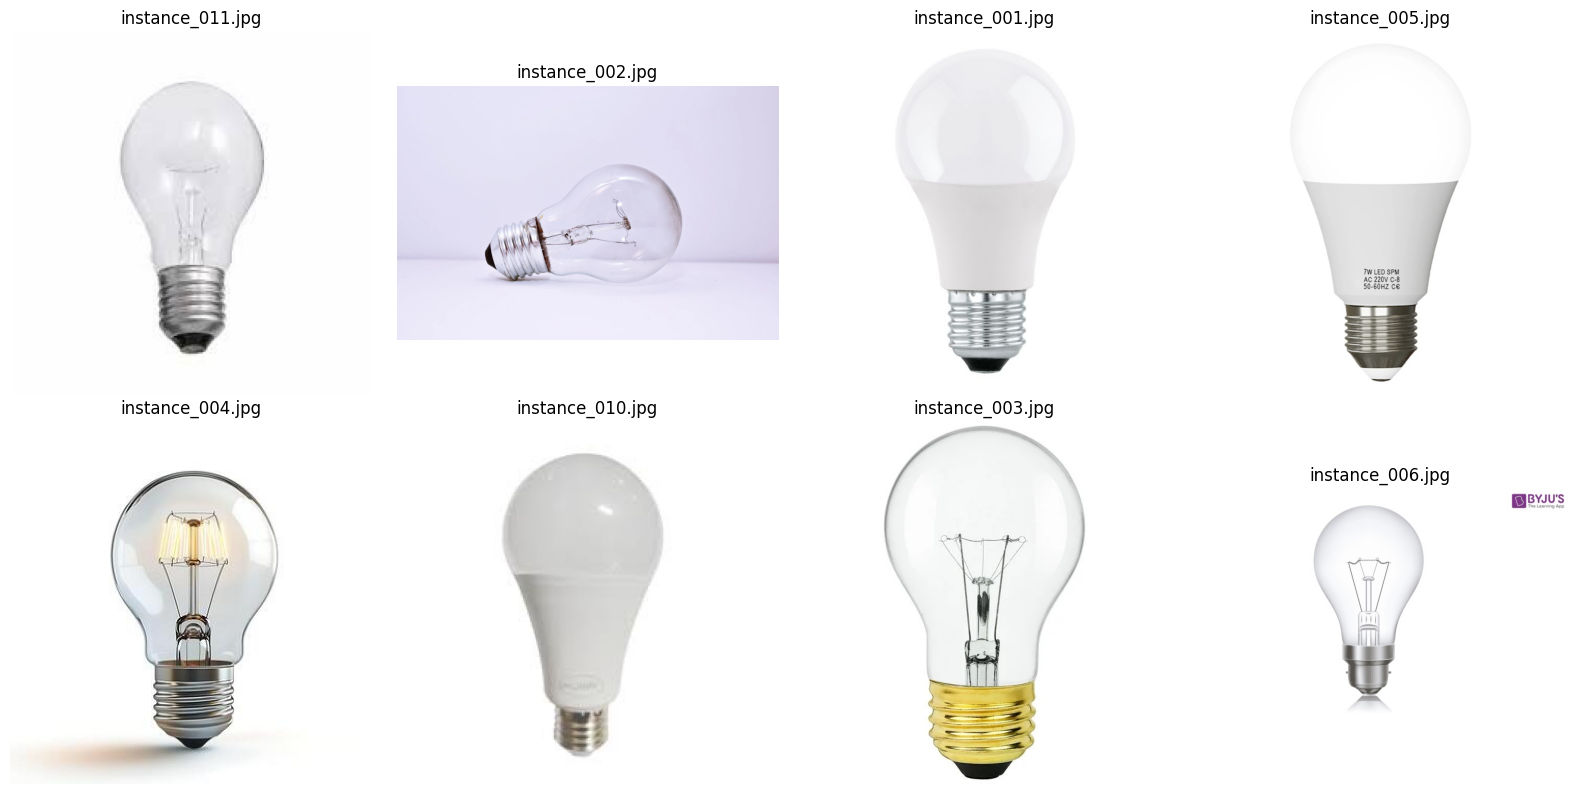

In [20]:
import math
import random
from PIL import Image
import matplotlib.pyplot as plt

image_paths = sorted([p for p in INSTANCE_DIR.rglob("*") if p.suffix.lower() in IMAGE_EXTENSIONS])

n_show = min(8, len(image_paths))
random.seed(42)
preview_paths = random.sample(image_paths, n_show) if len(image_paths) > n_show else image_paths

cols = 4
rows = math.ceil(n_show / cols)
plt.figure(figsize=(4 * cols, 4 * rows))
for i, p in enumerate(preview_paths, start=1):
    img = Image.open(p).convert("RGB")
    plt.subplot(rows, cols, i)
    plt.imshow(img)
    plt.title(p.name)
    plt.axis("off")
plt.tight_layout()
plt.show()


## 8. Вибір `unique_token` і `class_noun`

DreamBooth навчає модель пов'язувати спеціальний token із вашим об'єктом.

Формула:

```text
instance_prompt = "a photo of <unique_token> <class_noun>"
```

Приклади:

```text
a photo of zzcup cup
a photo of qxrobot toy
a photo of nplanta plant
a photo of vbag77 backpack
```

### Вимоги

- `unique_token` має бути вигаданим і рідкісним;
- `class_noun` має бути звичайним англійським словом класу: `cup`, `toy`, `plant`, `dog`, `backpack`;
- не використовуйте `my object`, `thing`, `photo`, `person`;
- prompts пишемо англійською.


In [21]:
# ===== НАЛАШТУВАННЯ PROMPT =====

if USE_HF_EXAMPLE_DATASET:
    UNIQUE_TOKEN = "sks"      # демонстраційний token із прикладів DreamBooth
    CLASS_NOUN = "dog"
else:
    UNIQUE_TOKEN = "jdsflightb"   # змініть на власний рідкісний token
    CLASS_NOUN = "bulb"        # змініть на клас вашого об'єкта

INSTANCE_PROMPT = f"a photo of {UNIQUE_TOKEN} {CLASS_NOUN}"
CLASS_PROMPT = f"a photo of a {CLASS_NOUN}"
VALIDATION_PROMPT = f"a photo of {UNIQUE_TOKEN} {CLASS_NOUN} in a studio"

print("UNIQUE_TOKEN:", UNIQUE_TOKEN)
print("CLASS_NOUN:", CLASS_NOUN)
print("INSTANCE_PROMPT:", INSTANCE_PROMPT)
print("CLASS_PROMPT:", CLASS_PROMPT)
print("VALIDATION_PROMPT:", VALIDATION_PROMPT)


UNIQUE_TOKEN: jdsflightb
CLASS_NOUN: bulb
INSTANCE_PROMPT: a photo of jdsflightb bulb
CLASS_PROMPT: a photo of a bulb
VALIDATION_PROMPT: a photo of jdsflightb bulb in a studio


## 9. Baseline: генерація base model до навчання

Перед fine-tuning треба згенерувати зображення звичайною base model. Потім ми порівняємо їх із результатами LoRA.

У baseline prompts **не використовуємо** `unique_token`, бо base model ще не знає вашого об'єкта.


In [22]:
# ===== НАЛАШТУВАННЯ МОДЕЛІ ТА ГЕНЕРАЦІЇ =====

MODEL_NAME = "stable-diffusion-v1-5/stable-diffusion-v1-5"
# Альтернатива, якщо основний repo недоступний у вашому середовищі:
# MODEL_NAME = "sd-legacy/stable-diffusion-v1-5"

SEED = 42
NUM_INFERENCE_STEPS = 35
GUIDANCE_SCALE = 7.5

BASELINE_DIR = WORK_DIR / "baseline_outputs"
LORA_OUTPUT_DIR = WORK_DIR / "dreambooth_lora_output"
LORA_RESULT_DIR = WORK_DIR / "lora_outputs"
COMPARISON_DIR = WORK_DIR / "comparison"

for d in [BASELINE_DIR, LORA_OUTPUT_DIR, LORA_RESULT_DIR, COMPARISON_DIR]:
    d.mkdir(parents=True, exist_ok=True)

CONTEXTS = [
    "on a wooden table",
    "in the snow",
    "in a futuristic kitchen",
    "floating in space",
]

baseline_prompts = [f"a photo of a {CLASS_NOUN} {context}" for context in CONTEXTS]
lora_prompts = [f"a photo of {UNIQUE_TOKEN} {CLASS_NOUN} {context}" for context in CONTEXTS]

print("Baseline prompts:")
for p in baseline_prompts:
    print("-", p)
print("\nLoRA prompts:")
for p in lora_prompts:
    print("-", p)


Baseline prompts:
- a photo of a bulb on a wooden table
- a photo of a bulb in the snow
- a photo of a bulb in a futuristic kitchen
- a photo of a bulb floating in space

LoRA prompts:
- a photo of jdsflightb bulb on a wooden table
- a photo of jdsflightb bulb in the snow
- a photo of jdsflightb bulb in a futuristic kitchen
- a photo of jdsflightb bulb floating in space


In [23]:
import gc
import torch
from diffusers import DiffusionPipeline, DPMSolverMultistepScheduler


def make_pipe(model_name: str):
    pipe = DiffusionPipeline.from_pretrained(
        model_name,
        torch_dtype=torch.float16,
        # Не примушуємо use_safetensors=True: деякі repo мають змішані .bin/.safetensors файли.
    )
    pipe.scheduler = DPMSolverMultistepScheduler.from_config(pipe.scheduler.config)
    pipe = pipe.to("cuda")
    pipe.enable_attention_slicing()
    pipe.safety_checker = None
    pipe.requires_safety_checker = False

    try:
        pipe.enable_xformers_memory_efficient_attention()
        print("xFormers memory efficient attention enabled.")
    except Exception as e:
        print("xFormers не ввімкнено:", repr(e))
    return pipe


def generate_and_save(pipe, prompts, out_dir: Path, prefix: str):
    out_dir.mkdir(parents=True, exist_ok=True)
    saved_paths = []
    generator = torch.Generator(device="cuda").manual_seed(SEED)
    for i, prompt in enumerate(prompts, start=1):
        image = pipe(
            prompt,
            num_inference_steps=NUM_INFERENCE_STEPS,
            guidance_scale=GUIDANCE_SCALE,
            generator=generator,
        ).images[0]
        path = out_dir / f"{prefix}_{i:02d}.png"
        image.save(path)
        saved_paths.append(path)
        print(f"Saved: {path} | {prompt}")
    return saved_paths


/usr/local/lib/python3.12/dist-packages/transformers/utils/hub.py:110: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(
2026-06-04 16:43:43.919878: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780591423.940569      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780591423.947191      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780591423.964262      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780591423.964284      58 computation_pl

In [24]:
# Генеруємо baseline-зображення.
base_pipe = make_pipe(MODEL_NAME)
baseline_paths = generate_and_save(base_pipe, baseline_prompts, BASELINE_DIR, "baseline")

del base_pipe
gc.collect()
torch.cuda.empty_cache()


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

safety_checker/model.safetensors:   0%|          | 0.00/1.22G [00:00<?, ?B/s]

text_encoder/model.safetensors:   0%|          | 0.00/492M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/472 [00:00<?, ?B/s]

...

Saved: /kaggle/working/baseline_outputs/baseline_02.png | a photo of a bulb in the snow


  0%|          | 0/35 [00:00<?, ?it/s]

Saved: /kaggle/working/baseline_outputs/baseline_03.png | a photo of a bulb in a futuristic kitchen


  0%|          | 0/35 [00:00<?, ?it/s]

Saved: /kaggle/working/baseline_outputs/baseline_04.png | a photo of a bulb floating in space


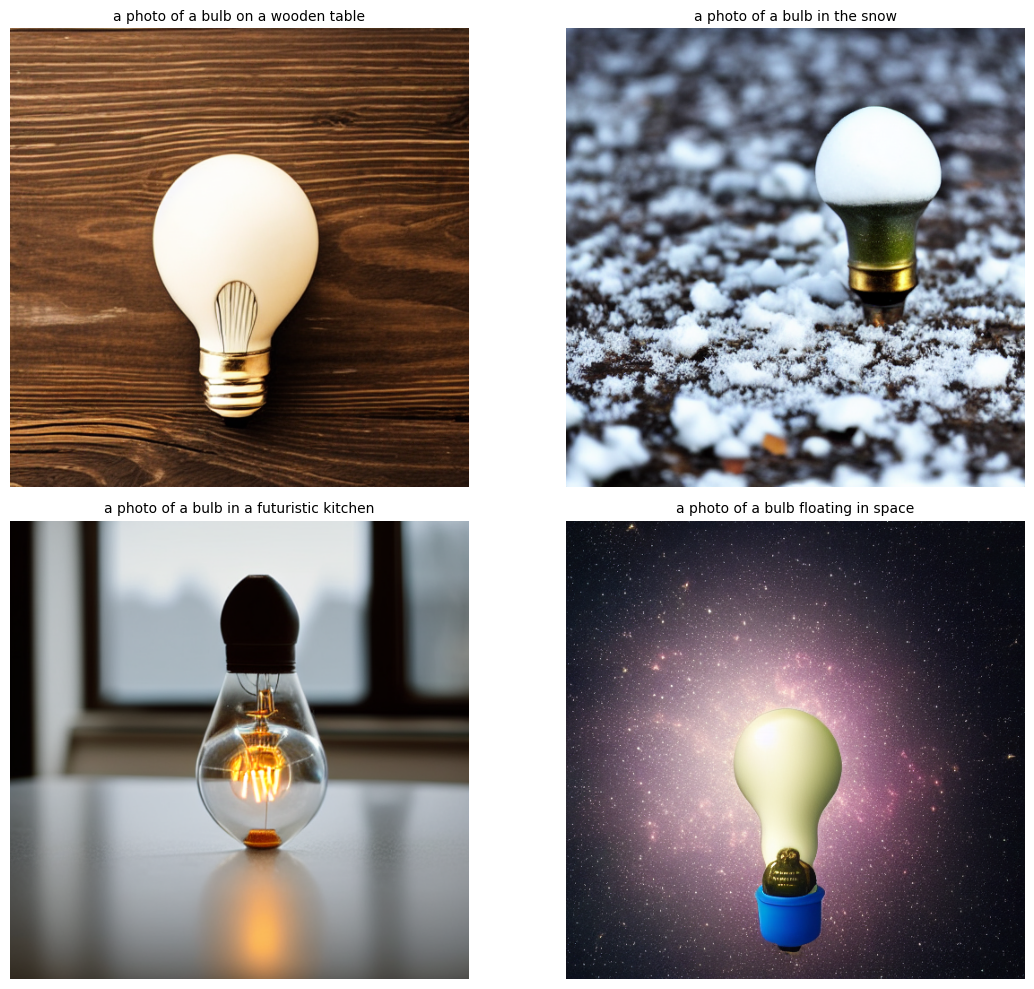

In [25]:
# Перегляд baseline-зображень.
from PIL import Image
import matplotlib.pyplot as plt
import math

cols = 2
rows = math.ceil(len(baseline_paths) / cols)
plt.figure(figsize=(6 * cols, 5 * rows))
for i, path in enumerate(baseline_paths, start=1):
    plt.subplot(rows, cols, i)
    plt.imshow(Image.open(path))
    plt.title(baseline_prompts[i - 1], fontsize=10)
    plt.axis("off")
plt.tight_layout()
plt.show()


## 10. Запуск DreamBooth LoRA training

Тут ми запускаємо офіційний script:

```text
/kaggle/working/train_dreambooth_lora.py
```

Стартові параметри підібрані для навчальної роботи. Якщо GPU слабкий або виникає `CUDA out of memory`, зменшіть `MAX_TRAIN_STEPS`, вимкніть validation або зменшіть `RESOLUTION` до 384.

### Рекомендовані стартові значення

| Параметр | Стартове значення |
|---|---:|
| `RESOLUTION` | 512 |
| `TRAIN_BATCH_SIZE` | 1 |
| `LEARNING_RATE` | 1e-4 |
| `MAX_TRAIN_STEPS` | 500 |
| `LORA_RANK` | 4 |
| `MIXED_PRECISION` | fp16 |
| `USE_8BIT_ADAM` | True |
| `GRADIENT_CHECKPOINTING` | True |


In [48]:
# ===== НАЛАШТУВАННЯ TRAINING =====

RESOLUTION = 512
TRAIN_BATCH_SIZE = 1
GRADIENT_ACCUMULATION_STEPS = 1
LEARNING_RATE = 1e-4
MAX_TRAIN_STEPS = 500
CHECKPOINTING_STEPS = 250
VALIDATION_EPOCHS = 25
NUM_VALIDATION_IMAGES = 2
LORA_RANK = 4
MIXED_PRECISION = "no"

USE_8BIT_ADAM = False
GRADIENT_CHECKPOINTING = True
ENABLE_XFORMERS = True  # xFormers не встановлюємо обов’язково у спрощеній версії
ALLOW_TF32 = True

# ===== PRIOR PRESERVATION =====
WITH_PRIOR_PRESERVATION = False  # Для базової лабораторної вимкнено

CLASS_DATA_DIR = WORK_DIR / "class_images"
CLASS_DATA_DIR.mkdir(parents=True, exist_ok=True)

CLASS_PROMPT = "a photo of a puppy"
NUM_CLASS_IMAGES = 30
PRIOR_LOSS_WEIGHT = 1.0

print("Training configuration")
print("MODEL_NAME:", MODEL_NAME)
print("INSTANCE_DIR:", INSTANCE_DIR)
print("LORA_OUTPUT_DIR:", LORA_OUTPUT_DIR)
print("INSTANCE_PROMPT:", INSTANCE_PROMPT)
print("MAX_TRAIN_STEPS:", MAX_TRAIN_STEPS)


Training configuration
MODEL_NAME: stable-diffusion-v1-5/stable-diffusion-v1-5
INSTANCE_DIR: /kaggle/working/instance_images
LORA_OUTPUT_DIR: /kaggle/working/dreambooth_lora_output
INSTANCE_PROMPT: a photo of jdsflightb bulb
MAX_TRAIN_STEPS: 500


### Формуємо команду тренування

In [49]:
import shlex
import subprocess
import importlib.util

cmd = [
    "accelerate", "launch",
    "--num_processes", "1",
    "--mixed_precision", MIXED_PRECISION,
    str(TRAIN_SCRIPT),

    "--pretrained_model_name_or_path", MODEL_NAME,
    "--instance_data_dir", str(INSTANCE_DIR),
    "--output_dir", str(LORA_OUTPUT_DIR),
    "--instance_prompt", INSTANCE_PROMPT,
    "--validation_prompt", VALIDATION_PROMPT,
    "--num_validation_images", str(NUM_VALIDATION_IMAGES),
    "--validation_epochs", str(VALIDATION_EPOCHS),
    "--resolution", str(RESOLUTION),
    "--train_batch_size", str(TRAIN_BATCH_SIZE),
    "--gradient_accumulation_steps", str(GRADIENT_ACCUMULATION_STEPS),
    "--learning_rate", str(LEARNING_RATE),
    "--lr_scheduler", "constant",
    "--lr_warmup_steps", "0",
    "--max_train_steps", str(MAX_TRAIN_STEPS),
    "--checkpointing_steps", str(CHECKPOINTING_STEPS),
    "--checkpoints_total_limit", "2",
    "--seed", str(SEED),
    "--rank", str(LORA_RANK),
]

if GRADIENT_CHECKPOINTING:
    cmd.append("--gradient_checkpointing")

if USE_8BIT_ADAM:
    if importlib.util.find_spec("bitsandbytes") is not None:
        cmd.append("--use_8bit_adam")
    else:
        print("bitsandbytes не знайдено, запускаємо без --use_8bit_adam")

if ENABLE_XFORMERS:
    if importlib.util.find_spec("xformers") is not None:
        cmd.append("--enable_xformers_memory_efficient_attention")
    else:
        print("xformers не знайдено, запускаємо без --enable_xformers_memory_efficient_attention")

if ALLOW_TF32:
    cmd.append("--allow_tf32")



### Prior Preservation у DreamBooth LoRA

У DreamBooth модель навчається пов’язувати новий унікальний токен з конкретним об’єктом.

Наприклад:

```python
INSTANCE_PROMPT = "a photo of sks puppy"
```

Тут `sks` — унікальний токен, а `puppy` — клас об’єкта.

Проблема DreamBooth полягає в тому, що під час навчання модель може занадто сильно “запам’ятати” конкретний об’єкт і частково зіпсувати загальне поняття класу. Наприклад, якщо ми навчаємо модель на одному конкретному цуценяті, вона може почати генерувати всіх `puppy` схожими саме на наш об’єкт. Це називають **overfitting** або **class drift**.

Щоб зменшити цю проблему, використовується методика **Prior Preservation**.

---

### Ідея Prior Preservation

Prior Preservation додає до навчання не тільки зображення конкретного об’єкта, але й звичайні зображення того самого класу.

Тобто модель бачить два типи прикладів:

| Тип даних | Приклад prompt | Що модель має вивчити |
|---|---|---|
| Instance images | `a photo of sks puppy` | конкретний об’єкт, пов’язаний із токеном `sks` |
| Class images | `a photo of a puppy` | загальне поняття класу `puppy` |

Таким чином модель навчається:

```text
sks puppy → конкретне цуценя
puppy     → загальний клас цуценят
```
---
### Як Prior Preservation працює всередині training loop

Якщо ввімкнено параметр:

```bash
--with_prior_preservation
```

то training batch містить два типи зображень:

1. **Instance images** — зображення конкретного об’єкта, наприклад:

   ```text
   a photo of sks puppy
   ```

2. **Class images** — звичайні зображення того самого класу, наприклад:

   ```text
   a photo of a puppy
   ```

Логіка навчання така:

1. Batch містить одночасно:

   ```text
   instance images + class images
   ```

2. `UNet` робить один `forward pass` для всього batch.

3. Результат `model_pred` розділяється на дві частини:

   - прогноз для `instance images`;
   - прогноз для `class images`.

4. Окремо рахується `instance loss`:

   ```text
   instance_loss = loss для конкретного об’єкта sks
   ```

5. Окремо рахується `prior loss`, або `class loss`:

   ```text
   prior_loss = loss для звичайних class images
   ```

6. Фінальна функція втрат обчислюється так:

   ```text
   total_loss = instance_loss + prior_loss_weight × prior_loss
   ```

Тобто `instance_loss` навчає модель відтворювати конкретний об’єкт, пов’язаний із токеном `sks`, а `prior_loss` допомагає моделі не забути загальне поняття класу, наприклад `corgi puppy`.

У коді офіційного `train_dreambooth_lora.py` це зазвичай реалізовано через розділення batch на дві частини:

```python
model_pred, model_pred_prior = torch.chunk(model_pred, 2, dim=0)
target, target_prior = torch.chunk(target, 2, dim=0)
```
---

### Що означають параметри

| Параметр | Призначення |
|---|---|
| `--with_prior_preservation` | Вмикає режим Prior Preservation |
| `--class_data_dir` | Папка, де зберігаються class images, тобто звичайні зображення об’єктів того самого класу. Офіційний train_dreambooth_lora.py сам генерує class images базовою Stable Diffusion моделлю, якщо в папці CLASS_DATA_DIR їх недостатньо |
| `--class_prompt` | Prompt для генерації або використання class images |
| `--num_class_images` | Кількість class images, яку потрібно мати для навчання |
| `--prior_loss_weight` | Вага class loss у загальній функції втрат |

---


Типове значення:

```python
PRIOR_LOSS_WEIGHT = 1.0
```

Якщо значення занадто велике, модель може слабше вивчити конкретний об’єкт.  
Якщо значення занадто мале, модель може сильніше overfit-нутися на конкретний об’єкт.

---

### Коли варто використовувати Prior Preservation

Prior Preservation корисний, якщо:

- dataset дуже малий;
- модель швидко overfit-иться;
- усі результати стають занадто схожими на навчальні фото;
- модель починає погано генерувати інші об’єкти того самого класу;
- потрібно краще зберегти загальне поняття класу.

In [50]:
# ===== PRIOR PRESERVATION =====
if WITH_PRIOR_PRESERVATION:
    cmd.extend([
        "--with_prior_preservation",
        "--class_data_dir", str(CLASS_DATA_DIR),
        "--class_prompt", CLASS_PROMPT,
        "--num_class_images", str(NUM_CLASS_IMAGES),
        "--prior_loss_weight", str(PRIOR_LOSS_WEIGHT),
    ])

### Роздруковуємо команду, яка запустить тренування

In [51]:
print("Команда training:")
print(" ".join(shlex.quote(x) for x in cmd))

Команда training:
accelerate launch --num_processes 1 --mixed_precision no /kaggle/working/train_dreambooth_lora.py --pretrained_model_name_or_path stable-diffusion-v1-5/stable-diffusion-v1-5 --instance_data_dir /kaggle/working/instance_images --output_dir /kaggle/working/dreambooth_lora_output --instance_prompt 'a photo of jdsflightb bulb' --validation_prompt 'a photo of jdsflightb bulb in a studio' --num_validation_images 2 --validation_epochs 25 --resolution 512 --train_batch_size 1 --gradient_accumulation_steps 1 --learning_rate 0.0001 --lr_scheduler constant --lr_warmup_steps 0 --max_train_steps 500 --checkpointing_steps 250 --checkpoints_total_limit 2 --seed 42 --rank 4 --gradient_checkpointing --enable_xformers_memory_efficient_attention --allow_tf32


### Запуск тренування

In [52]:
import subprocess
import sys
import os
from pathlib import Path

log_path = Path("/kaggle/working/training_live.log")

env = os.environ.copy()
env["PYTHONUNBUFFERED"] = "1"

with open(log_path, "w", encoding="utf-8") as log_file:
    process = subprocess.Popen(
        cmd,
        cwd=str(TRAIN_SCRIPT.parent),
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
        env=env,
    )

    for line in process.stdout:
        print(line, end="", flush=True)
        log_file.write(line)
        log_file.flush()

    return_code = process.wait()

print("Return code:", return_code)
print("Log saved to:", log_path)

if return_code != 0:
    raise RuntimeError(f"Training завершився з помилкою. Return code: {return_code}")
else:
    print("Training завершено успішно.")

/usr/local/lib/python3.12/dist-packages/transformers/utils/hub.py:110: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(
The following values were not passed to `accelerate launch` and had defaults used instead:
	`--num_machines` was set to a value of `1`
	`--dynamo_backend` was set to a value of `'no'`
To avoid this warning pass in values for each of the problematic parameters or run `accelerate config`.
/usr/local/lib/python3.12/dist-packages/transformers/utils/hub.py:110: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(
2026-06-04 17:02:35.812373: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780592555.835871     382 cuda_dnn.cc:8579] Unable to register cuDNN f

In [ ]:
# Перевіряємо, які файли збережено після training.
!find /kaggle/working/dreambooth_lora_output -maxdepth 3 -type f | sort


## 11. Inference після навчання

Тепер завантажуємо base model і підключаємо LoRA weights із `LORA_OUTPUT_DIR`.

Для fine-tuned prompts використовуємо `unique_token`, наприклад:

```text
a photo of sks puppy in the snow
```


In [53]:
# Генерація з LoRA weights.
lora_pipe = make_pipe(MODEL_NAME)

lora_pipe.load_lora_weights(str(LORA_OUTPUT_DIR))
print("LoRA weights loaded from:", LORA_OUTPUT_DIR)

lora_paths = generate_and_save(lora_pipe, lora_prompts, LORA_RESULT_DIR, "lora")

del lora_pipe
gc.collect()
torch.cuda.empty_cache()

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

xFormers memory efficient attention enabled.


No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new


LoRA weights loaded from: /kaggle/working/dreambooth_lora_output


  0%|          | 0/35 [00:00<?, ?it/s]

...

Saved: /kaggle/working/lora_outputs/lora_02.png | a photo of jdsflightb bulb in the snow


  0%|          | 0/35 [00:00<?, ?it/s]

Saved: /kaggle/working/lora_outputs/lora_03.png | a photo of jdsflightb bulb in a futuristic kitchen


  0%|          | 0/35 [00:00<?, ?it/s]

Saved: /kaggle/working/lora_outputs/lora_04.png | a photo of jdsflightb bulb floating in space


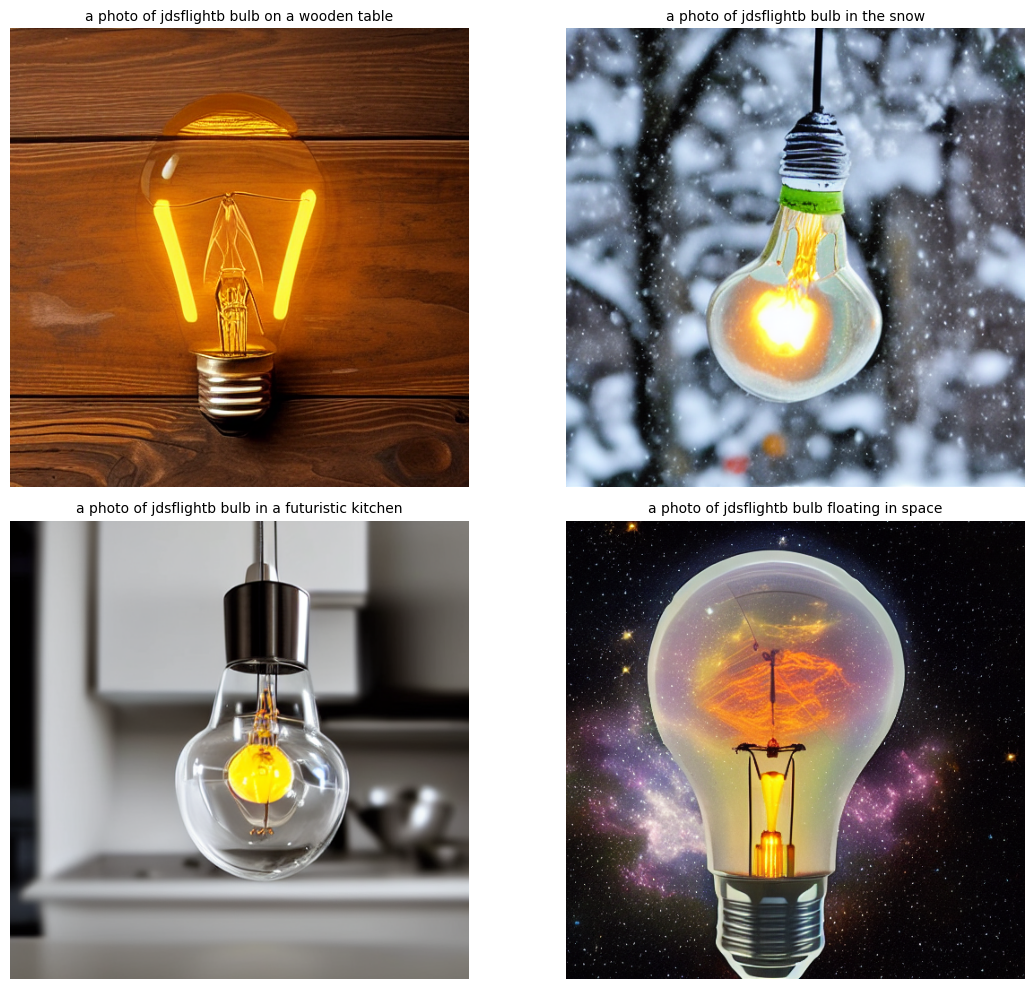

In [55]:
# Перегляд fine-tuned LoRA результатів.
cols = 2
rows = math.ceil(len(lora_paths) / cols)
plt.figure(figsize=(6 * cols, 5 * rows))
for i, path in enumerate(lora_paths, start=1):
    plt.subplot(rows, cols, i)
    plt.imshow(Image.open(path))
    plt.title(lora_prompts[i - 1], fontsize=10)
    plt.axis("off")
plt.tight_layout()
plt.show()


## 12. Порівняння base model vs fine-tuned model

Порівнюємо:

- ліворуч: base model без знання вашого конкретного об'єкта;
- праворуч: base model + LoRA weights із вашим `unique_token`.

Оцінюємо не тільки естетику, а й те, чи зберігся об'єкт і чи змінився контекст.


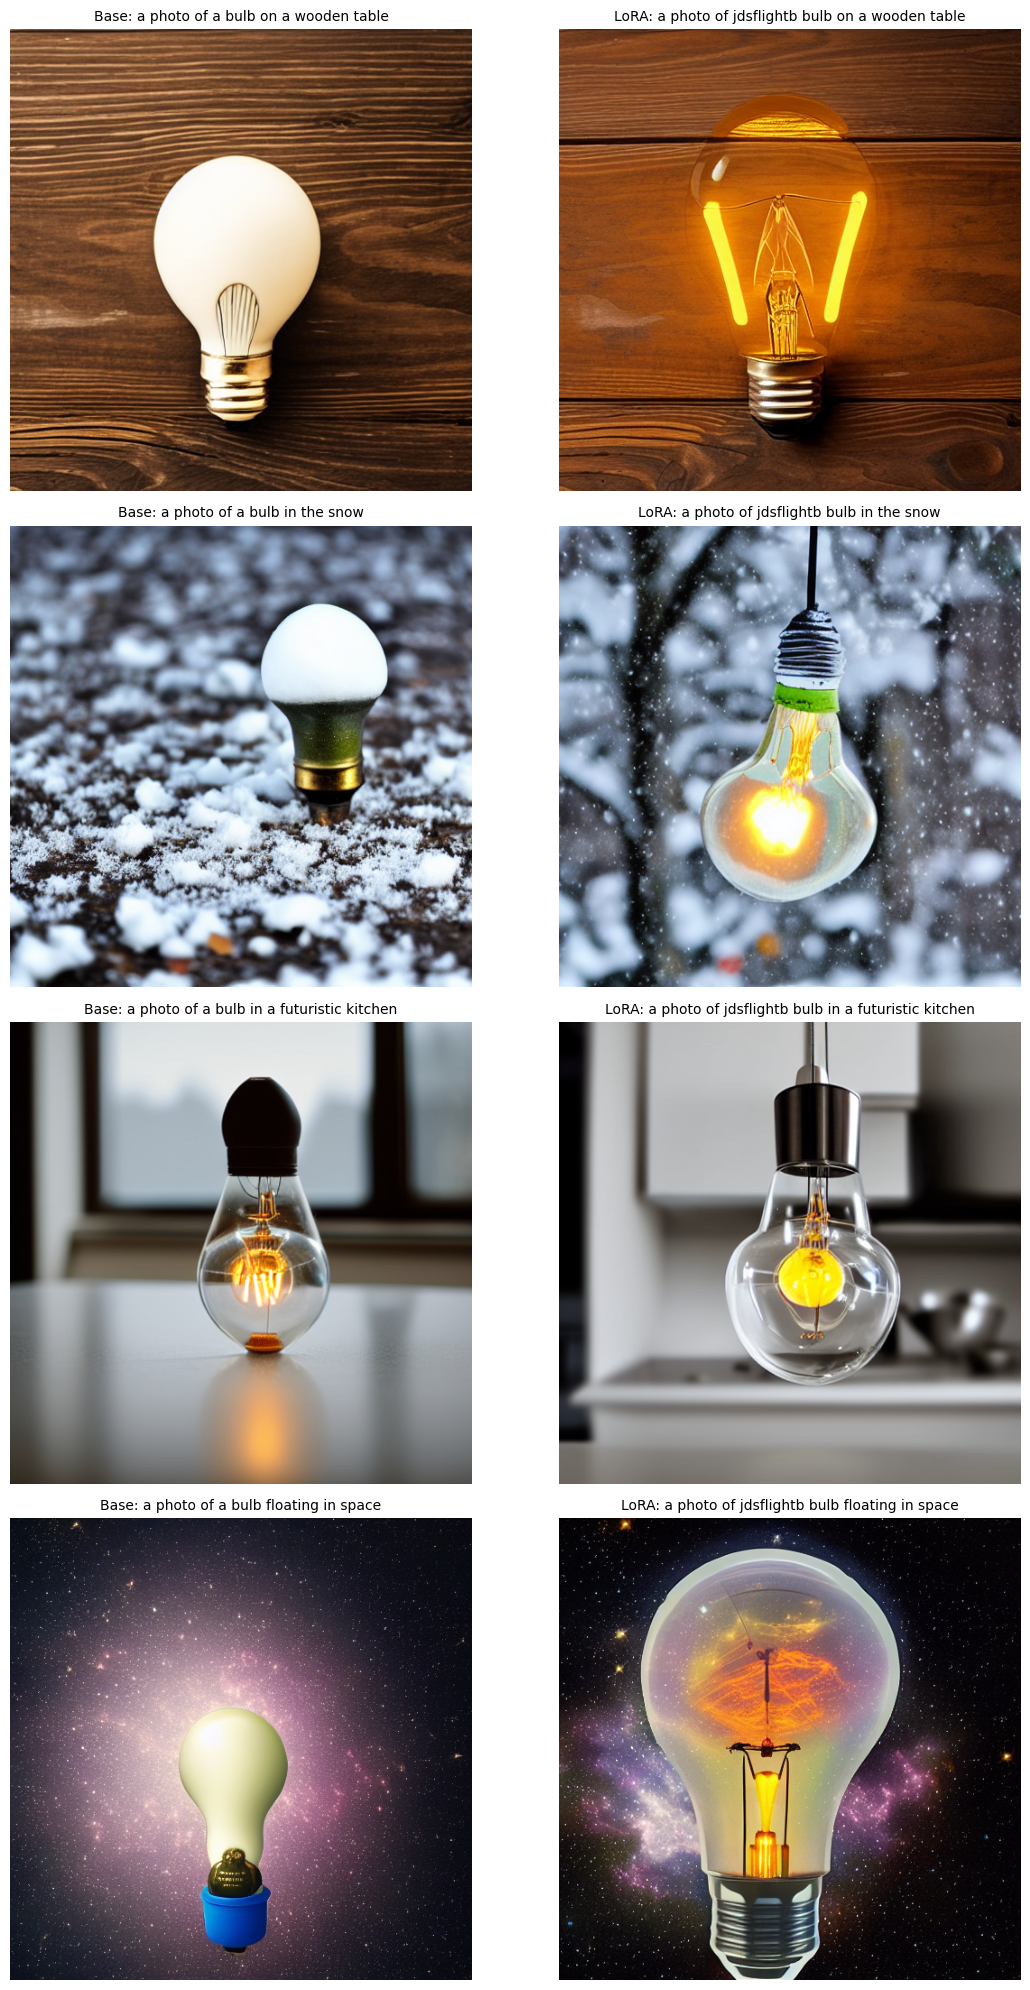

In [56]:
# Порівняльна таблиця зображень.
import matplotlib.pyplot as plt
from PIL import Image

n = min(len(baseline_paths), len(lora_paths))
plt.figure(figsize=(12, 5 * n))
for i in range(n):
    plt.subplot(n, 2, 2 * i + 1)
    plt.imshow(Image.open(baseline_paths[i]))
    plt.title("Base: " + baseline_prompts[i], fontsize=10)
    plt.axis("off")

    plt.subplot(n, 2, 2 * i + 2)
    plt.imshow(Image.open(lora_paths[i]))
    plt.title("LoRA: " + lora_prompts[i], fontsize=10)
    plt.axis("off")

plt.tight_layout()
plt.show()


In [57]:
# Збережемо простий comparison grid у файл для звіту.
from PIL import Image, ImageDraw, ImageFont

thumb_w, thumb_h = 512, 512
label_h = 80
grid_w = thumb_w * 2
lower_margin = 10
grid_h = (thumb_h + label_h + lower_margin) * n

canvas = Image.new("RGB", (grid_w, grid_h), "white")
draw = ImageDraw.Draw(canvas)

for i in range(n):
    y = i * (thumb_h + label_h + lower_margin)
    left = Image.open(baseline_paths[i]).convert("RGB").resize((thumb_w, thumb_h))
    right = Image.open(lora_paths[i]).convert("RGB").resize((thumb_w, thumb_h))
    canvas.paste(left, (0, y + label_h))
    canvas.paste(right, (thumb_w, y + label_h))
    draw.text((10, y + 10), "BASE: " + baseline_prompts[i], fill="black")
    draw.text((thumb_w + 10, y + 10), "LORA: " + lora_prompts[i], fill="black")

comparison_path = COMPARISON_DIR / "base_vs_lora_comparison.jpg"
canvas.save(comparison_path, quality=95)
print("Saved comparison:", comparison_path)


Saved comparison: /kaggle/working/comparison/base_vs_lora_comparison.jpg


## 13. Аналіз результатів

Заповніть таблицю нижче після перегляду зображень.

### Ознаки underfitting

Модель **не навчилась** вашого об'єкта:

- об'єкт не впізнається;
- `unique_token` майже не впливає на результат;
- генерується просто типовий `class_noun`.

Що робити:

- збільшити `MAX_TRAIN_STEPS`;
- покращити dataset;
- перевірити `INSTANCE_PROMPT`;
- додати різні ракурси й освітлення.

### Ознаки overfitting

Модель **занадто сильно запам'ятала** training images:

- повторюються ті самі ракурси, фон або композиція;
- контекст із prompt ігнорується;
- з'являються артефакти;
- об'єкт копіюється майже як на навчальних фото.

Що робити:

- зменшити `MAX_TRAIN_STEPS`;
- зменшити `LEARNING_RATE`;
- додати різноманітніші фото;
- не використовувати майже однакові кадри.


In [58]:
# Шаблон таблиці для аналізу. Студент може заповнити колонки вручну у звіті.
import pandas as pd

analysis_table = pd.DataFrame({
    "prompt": lora_prompts,
    "object_recognizable_1_to_5": [None] * len(lora_prompts),
    "context_followed_1_to_5": [None] * len(lora_prompts),
    "artifacts_or_errors": ["" for _ in lora_prompts],
    "overfitting_signs": ["" for _ in lora_prompts],
    "comments": ["" for _ in lora_prompts],
})

analysis_csv = WORK_DIR / "analysis_template.csv"
analysis_table.to_csv(analysis_csv, index=False)
analysis_table


,prompt,object_recognizable_1_to_5,context_followed_1_to_5,artifacts_or_errors,overfitting_signs,comments
0,a photo of jdsflightb bulb on a wooden table,None,None,,,
1,a photo of jdsflightb bulb in the snow,None,None,,,
2,a photo of jdsflightb bulb in a futuristic kit...,None,None,,,
3,a photo of jdsflightb bulb floating in space,None,None,,,


## 14. Завдання на "Відмінно"

Спробуйте різні налаштування і порівняйте результат:

1. Зменшити `MAX_TRAIN_STEPS` до 100.
2. Збільшити `MAX_TRAIN_STEPS` до 500-800.
3. Змінити `LEARNING_RATE` з `5e-5` на `1e-4`.
4. Змінити `LORA_RANK` з 4 на 8.
5. Додайте prior preservation через WITH_PRIOR_PRESERVATION.

У звіті повторіть пункти звіту 4-6 для обраних наборів параметрів. Поясніть, що саме змінилося у кожному випадку і чому.


## 15. Шаблон базового звіту

Скопіюйте цей шаблон у свій звіт і заповніть.

---

# Звіт до лабораторної /роботи: DreamBooth LoRA

### 1. Мета роботи

Коротко сформулювати мету: персоналізувати Stable Diffusion за допомогою DreamBooth LoRA на невеликому dataset одного об'єкта.

### 2. Опис датасету

- Об'єкт:
- Кількість зображень:
- Джерело зображень:
- Чи є дозвіл на використання:
- Чи містять зображення людей / приватні дані:
- Які ракурси й умови освітлення використано:

Додати grid із 4–8 training images або опис, якщо фото приватні.

### 3. Prompt design

- `unique_token`:
- `class_noun`:
- `instance_prompt`:
- `validation_prompt`:

### 4. Параметри training

| Параметр | Значення |
|---|---:|
| Base model | |
| Resolution | |
| Train batch size | |
| Gradient accumulation | |
| Learning rate | |
| Max train steps | |
| LoRA rank | |
| Mixed precision | |
| 8-bit Adam | |
| Gradient checkpointing | |

### 5. Baseline results

Вставити 2–4 зображення base model і prompts до них.

### 6. Fine-tuned LoRA results

Вставити 2–4 зображення після LoRA training і prompts до них.

### 7. Порівняння base vs LoRA

Вставити `base_vs_lora_comparison.jpg`.

Відповісти:

1. Чи впізнається навчальний об'єкт?
2. Чи змінився контекст відповідно до prompt?
3. Який prompt спрацював найкраще?
4. Який prompt спрацював найгірше?
5. Чи видно ознаки overfitting?
6. Чи видно ознаки underfitting?

### 8. Висновок

Коротко описати, що вдалося, що не вдалося і які зміни могли б покращити результат.

---


## 16. Джерела

- Hugging Face Diffusion Course — DreamBooth Hackathon: https://huggingface.co/learn/diffusion-course/hackathon/dreambooth
- Diffusers DreamBooth training docs: https://huggingface.co/docs/diffusers/training/dreambooth
- Official Diffusers DreamBooth LoRA script: https://github.com/huggingface/diffusers/blob/main/examples/dreambooth/train_dreambooth_lora.py
- Stable Diffusion v1.5 model card: https://huggingface.co/stable-diffusion-v1-5/stable-diffusion-v1-5
- Hugging Face Hub environment variables: https://huggingface.co/docs/huggingface_hub/en/package_reference/environment_variables
